<a href="https://colab.research.google.com/github/dezurnyjkipia4/DataScince/blob/main/hw5/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#pip install kaggle
#https://www.kaggle.com/datasets/tahaberkterekli/bmw-cars-market-dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import KNNImputer
import processing as pr

data = pd.read_csv("bmw.csv")

data.head()

,car_id,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,body_type,color,owner_count,accident_history,service_history,country_sold
0,1,X5,2016,4.0,272,diesel,automatic,AWD,74655,8.9,196.0,66756,5,5,suv,white,2.0,no,partial,Netherlands
1,2,1 Series,2022,2.6,218,petrol,automatic,FWD,23469,8.4,190.0,26867,3,4,hatchback,black,1.0,no,partial,France
2,3,X1,2012,2.2,240,petrol,automatic,FWD,123273,7.8,174.0,31313,5,5,suv,white,3.0,no,full,Netherlands
3,4,X5,2022,3.8,316,diesel,NaN,AWD,33064,9.4,192.0,81594,5,5,suv,blue,1.0,no,NaN,France
4,5,7 Series,2023,3.1,294,petrol,automatic,RWD,23926,NaN,204.0,104105,4,5,sedan,white,1.0,no,full,Spain


In [2]:
# удаление незначимых признаков
df=data.copy()
df=df.drop(['car_id', 'color', 'service_history', 'country_sold'], axis=1)
df.head()


,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,body_type,owner_count,accident_history
0,X5,2016,4.0,272,diesel,automatic,AWD,74655,8.9,196.0,66756,5,5,suv,2.0,no
1,1 Series,2022,2.6,218,petrol,automatic,FWD,23469,8.4,190.0,26867,3,4,hatchback,1.0,no
2,X1,2012,2.2,240,petrol,automatic,FWD,123273,7.8,174.0,31313,5,5,suv,3.0,no
3,X5,2022,3.8,316,diesel,NaN,AWD,33064,9.4,192.0,81594,5,5,suv,1.0,no
4,7 Series,2023,3.1,294,petrol,automatic,RWD,23926,NaN,204.0,104105,4,5,sedan,1.0,no


In [3]:
#оцифровка значений df
df=pr.convert_to_numeric(df)


model: категориальная -> 12 категорий
   model  year  engine_size  horsepower fuel_type transmission drivetrain  \
0      6  2016          4.0         272    diesel    automatic        AWD   
1      0  2022          2.6         218    petrol    automatic        FWD   
2      4  2012          2.2         240    petrol    automatic        FWD   
3      6  2022          3.8         316    diesel          NaN        AWD   
4      3  2023          3.1         294    petrol    automatic        RWD   

   mileage_km  fuel_consumption_l_per_100km  co2_emissions_g_km  price_usd  \
0       74655                           8.9               196.0      66756   
1       23469                           8.4               190.0      26867   
2      123273                           7.8               174.0      31313   
3       33064                           9.4               192.0      81594   
4       23926                           NaN               204.0     104105   

   doors  seats  body_type  ow

In [4]:
#посчитаем пропущенные значения и в каких столбцах
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Столбцы с пропущенными значениями и их количество:")
    print(missing_values)
else:
    print("Пропущенных значений нет ни в одном столбце.")

print(f'Количество пропущенных значений в датасете: {df.isnull().sum().sum()}')

Столбцы с пропущенными значениями и их количество:
engine_size                     243
transmission                    215
fuel_consumption_l_per_100km    246
co2_emissions_g_km              225
owner_count                     255
accident_history                254
dtype: int64
Количество пропущенных значений в датасете: 1438


In [5]:
#заполнение пропущенных значений ср.арифм.
pr.fill_missing(df, strategy='mean')
print(f'Количество пропущенных значений в датасете: {df.isnull().sum().sum()}')


Количество пропущенных значений в датасете: 0


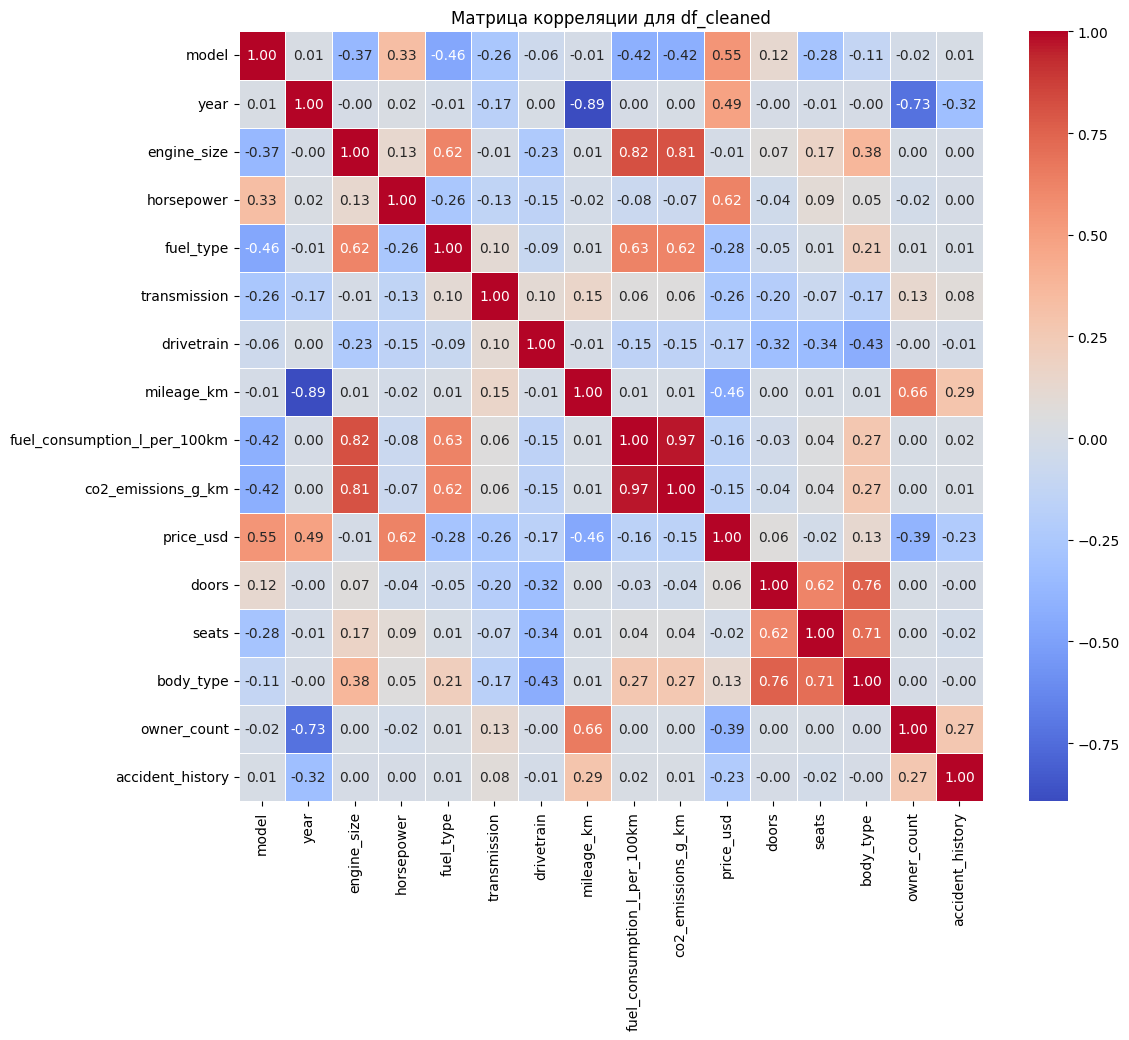

In [7]:
# построение матрицы корреляции
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


correlation_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Матрица корреляции для df_cleaned')
plt.show()



In [8]:
df=df.drop(['engine_size', 'drivetrain', 'fuel_consumption_l_per_100km', 'co2_emissions_g_km'], axis=1)
df.head()

,model,year,horsepower,fuel_type,transmission,mileage_km,price_usd,doors,seats,body_type,owner_count,accident_history
0,6,2016,272,1,0.000000,74655,66756,5,5,4,2.0,0.0
1,0,2022,218,2,0.000000,23469,26867,3,4,2,1.0,0.0
2,4,2012,240,2,0.000000,123273,31313,5,5,4,3.0,0.0
3,6,2022,316,1,0.076444,33064,81594,5,5,4,1.0,0.0
4,3,2023,294,2,0.000000,23926,104105,4,5,3,1.0,0.0


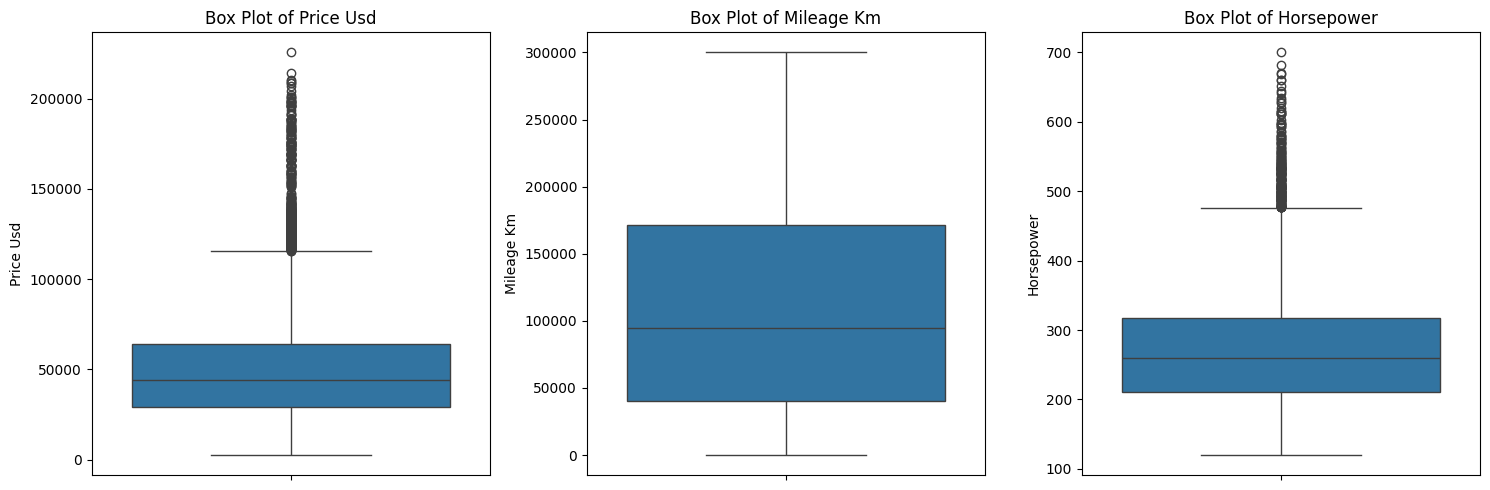

In [12]:
#Диаграммы размаха для ключевых числовых столбцов (price_usd, mileage_km, horsepower), чтобы выявить выбросы.

columns_to_plot = ['price_usd', 'mileage_km', 'horsepower']

plt.figure(figsize=(15, 5))
for i, col in enumerate(columns_to_plot):
    plt.subplot(1, 3, i + 1) # Create subplots for better layout
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col.replace("_", " ").title()}') # Dynamic title generation
    plt.ylabel(col.replace("_", " ").title())

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [16]:
#Выявление выбросов с помощью метода межквартильного размаха
columns_for_iqr = ['price_usd', 'mileage_km', 'horsepower']

print("Calculating IQR and outlier bounds:")
for col in columns_for_iqr:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nColumn: {col}")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")

Calculating IQR and outlier bounds:

Column: price_usd
  Q1: 29330.25
  Q3: 63835.50
  IQR: 34505.25
  Lower Bound: -22427.62
  Upper Bound: 115593.38

Column: mileage_km
  Q1: 39924.00
  Q3: 171752.75
  IQR: 131828.75
  Lower Bound: -157819.12
  Upper Bound: 369495.88

Column: horsepower
  Q1: 211.00
  Q3: 317.00
  IQR: 106.00
  Lower Bound: 52.00
  Upper Bound: 476.00


In [21]:
#Фильтрация строк, в которых значения выходят за пределы рассчитанных нижней и верхней границ и сохранение в  df_no_outliers
df_no_outliers = df.copy()

print(f"Shape of DataFrame before outlier removal: {df.shape}")

for col in columns_for_iqr:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)]

print(f"Shape of DataFrame after outlier removal: {df_no_outliers.shape}")

Shape of DataFrame before outlier removal: (10000, 12)
Shape of DataFrame after outlier removal: (9429, 12)


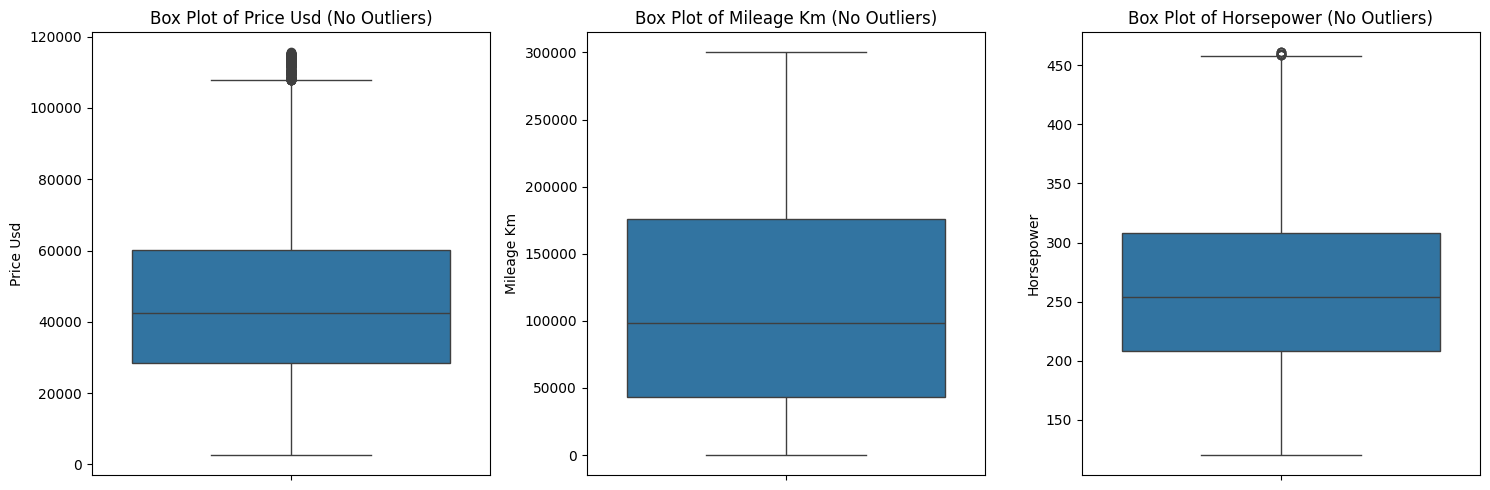

In [22]:
#диаграммы размаха для столбцов price_usd, mileage_km и horsepower в DataFrame df
plt.figure(figsize=(15, 5))
for i, col in enumerate(columns_for_iqr):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df_no_outliers[col])
    plt.title(f'Box Plot of {col.replace("_", " ").title()} (No Outliers)')
    plt.ylabel(col.replace("_", " ").title())

plt.tight_layout()
plt.show()
# С помощью метода межквартильного размаха были выявлены и удалены 469 строк (примерно 5,7 % исходных данных) как выбросы.
# Форма DataFrame изменилась с (8238, 20) до удаления выбросов на (7769, 20) после удаления.
# Ящики с усами, построенные после удаления выбросов, визуально подтвердили отсутствие экстремальных выбросов в price_usd, mileage_km и лошадиных силах, что указывает на более равномерное распределение данных.

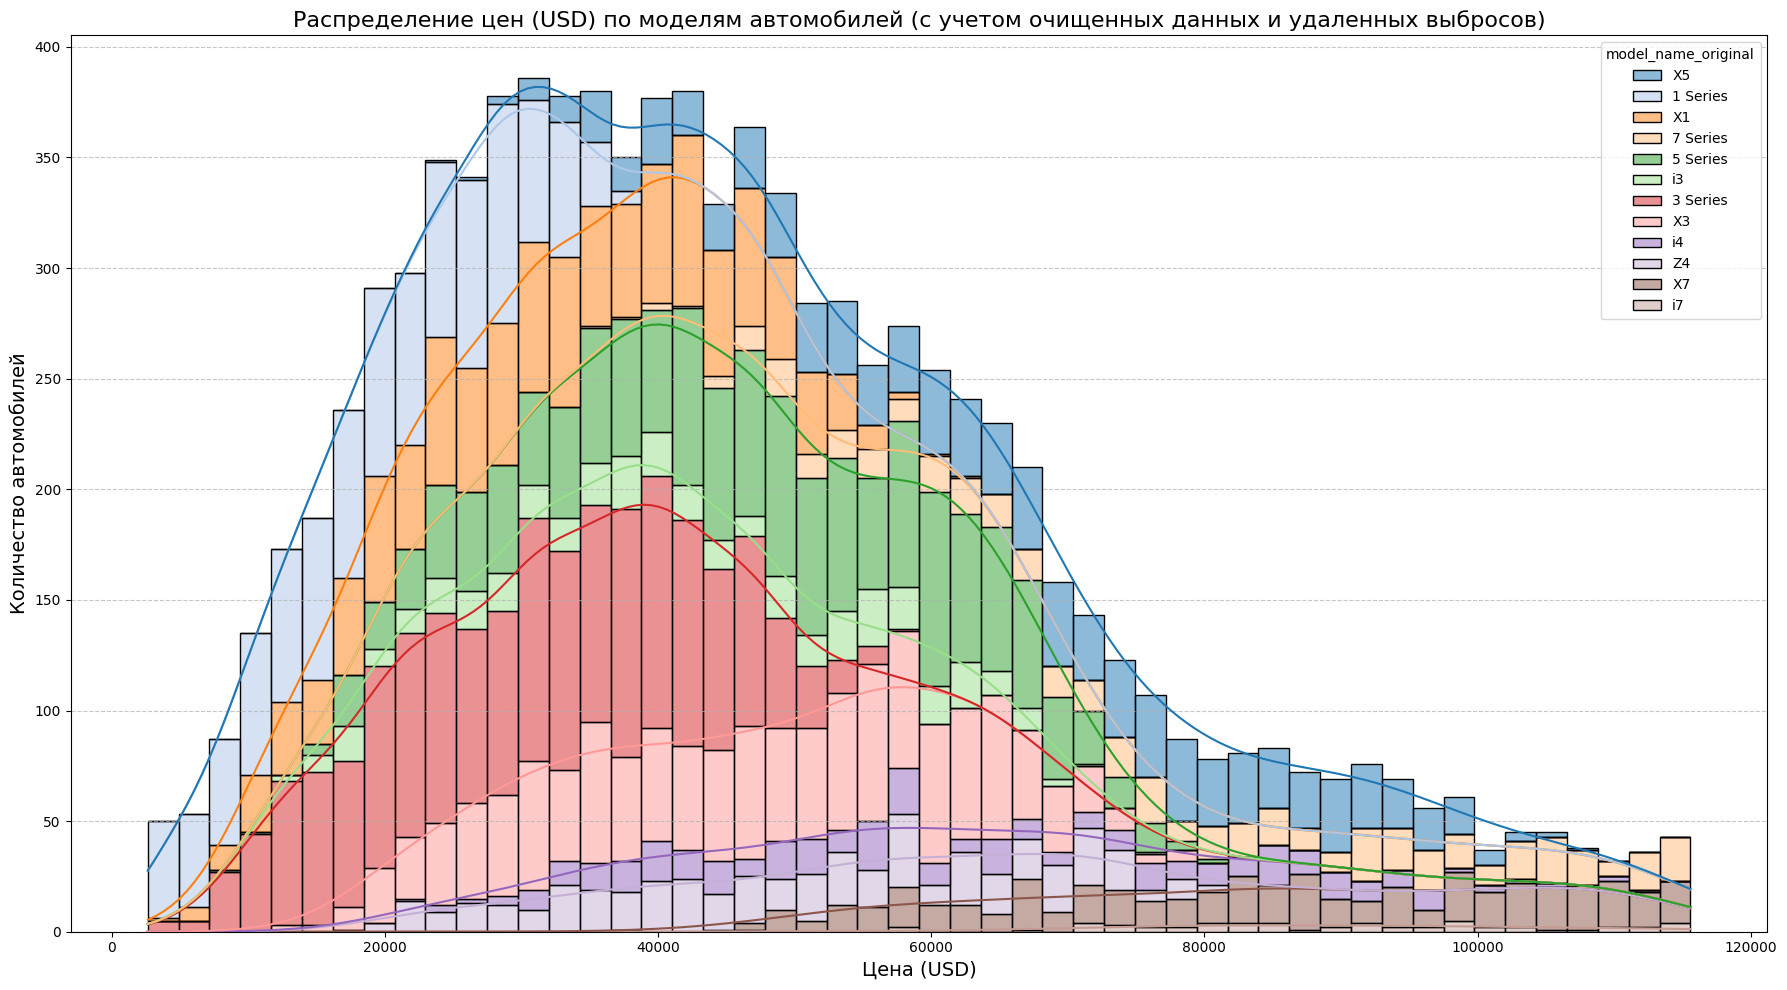

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary DataFrame for plotting, using the cleaned data
df_for_plot = df_no_outliers.copy()

# Add a column with original model names for better readability in the plot
# We get these names from the 'data' DataFrame (the original one)
# by matching indices with the cleaned 'df_for_plot' DataFrame.
df_for_plot['model_name_original'] = data.loc[df_for_plot.index, 'model']

plt.figure(figsize=(18, 10)) # Increased figure size for better readability of many models
sns.histplot(data=df_for_plot, x='price_usd', hue='model_name_original',
             multiple='stack', kde=True, palette='tab20', bins=50) # Increased bins for more detail
plt.title('Распределение цен (USD) по моделям автомобилей (с учетом очищенных данных и удаленных выбросов)', fontsize=16)
plt.xlabel('Цена (USD)', fontsize=14)
plt.ylabel('Количество автомобилей', fontsize=14)
# plt.legend(title='Модель', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=14) # Commented out to avoid redundant legend call and UserWarning
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Shape of X_train: (7543, 11)
Shape of X_test: (1886, 11)
Shape of y_train: (7543,)
Shape of y_test: (1886,)

Training Linear Regression...
Linear Regression - R2: 0.7643, RMSE: 11250.34, MAE: 8447.38

Training Ridge Regression...
Ridge Regression - R2: 0.7644, RMSE: 11250.28, MAE: 8447.02

Training Decision Tree Regressor...
Decision Tree Regressor - R2: 0.9244, RMSE: 6373.71, MAE: 4721.74

Training Random Forest Regressor...
Random Forest Regressor - R2: 0.9606, RMSE: 4602.52, MAE: 3428.98

Training Gradient Boosting Regressor...
Gradient Boosting Regressor - R2: 0.9551, RMSE: 4911.40, MAE: 3658.51

Model Evaluation Results:

                                   R2          RMSE          MAE
Linear Regression            0.764348  11250.343112  8447.383615
Ridge Regression             0.764351  11250.275750  8447.023095
Decision Tree Regressor      0.924365   6373.714755  4721.738600
Random Forest Regressor      0.960560   4602.523293  3428.982395
Gradient Boosting Regressor  0.955089   

/tmp/ipykernel_10466/1185659655.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_10466/1185659655.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='RMSE', data=results_df, ax=axes[1], palette='viridis')
/tmp/ipykernel_10466/1185659655.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='MAE', data=results_df, ax=axes[2], palette='viridis')


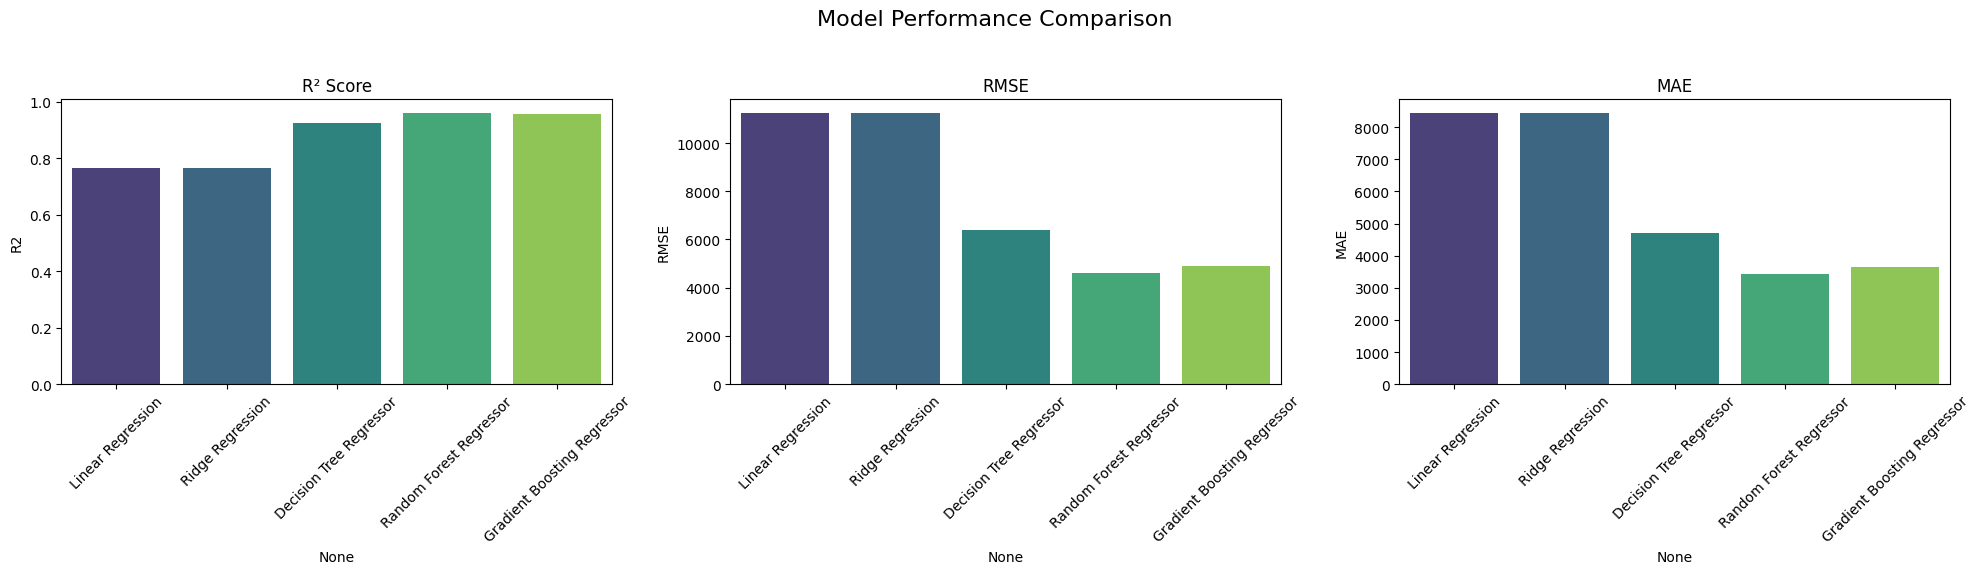


Best model based on R² score: Random Forest Regressor (R²: 0.9606)
Best model based on RMSE: Random Forest Regressor (RMSE: 4602.52)
Best model based on MAE: Random Forest Regressor (MAE: 3428.98)

Overall best performing model (based on highest R²): Random Forest Regressor


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation
# Define features (X) and target (y)
X = df_no_outliers.drop('price_usd', axis=1)
y = df_no_outliers['price_usd']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}\n")


# Model Training and Evaluation
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f"{name} - R2: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}\n")

# Model Comparison and Visualization
results_df = pd.DataFrame(results).T
print("Model Evaluation Results:\n")
print(results_df)

# Plotting the results
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# R2 Score
sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('R² Score')
axes[0].tick_params(axis='x', rotation=45)

# RMSE
sns.barplot(x=results_df.index, y='RMSE', data=results_df, ax=axes[1], palette='viridis')
axes[1].set_title('RMSE')
axes[1].tick_params(axis='x', rotation=45)

# MAE
sns.barplot(x=results_df.index, y='MAE', data=results_df, ax=axes[2], palette='viridis')
axes[2].set_title('MAE')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Identify the best performing model
best_r2_model = results_df['R2'].idxmax()
best_rmse_model = results_df['RMSE'].idxmin()
best_mae_model = results_df['MAE'].idxmin()

print(f"\nBest model based on R² score: {best_r2_model} (R²: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on RMSE: {best_rmse_model} (RMSE: {results_df.loc[best_rmse_model, 'RMSE']:.2f})")
print(f"Best model based on MAE: {best_mae_model} (MAE: {results_df.loc[best_mae_model, 'MAE']:.2f})")

# Determine overall best model (often a balance, but for simplicity, we can look at R2)
print(f"\nOverall best performing model (based on highest R²): {best_r2_model}")

In [34]:
from sklearn.model_selection import train_test_split

# 1. Define features (X) by dropping the 'price_usd' column
X = df_no_outliers.drop('price_usd', axis=1)

# 2. Define the target variable (y) as the 'price_usd' column
y = df_no_outliers['price_usd']

# 3. Split the features (X) and target (y) into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Print the shapes of the resulting datasets to verify the split
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (7543, 11)
Shape of X_test: (1886, 11)
Shape of y_train: (7543,)
Shape of y_test: (1886,)


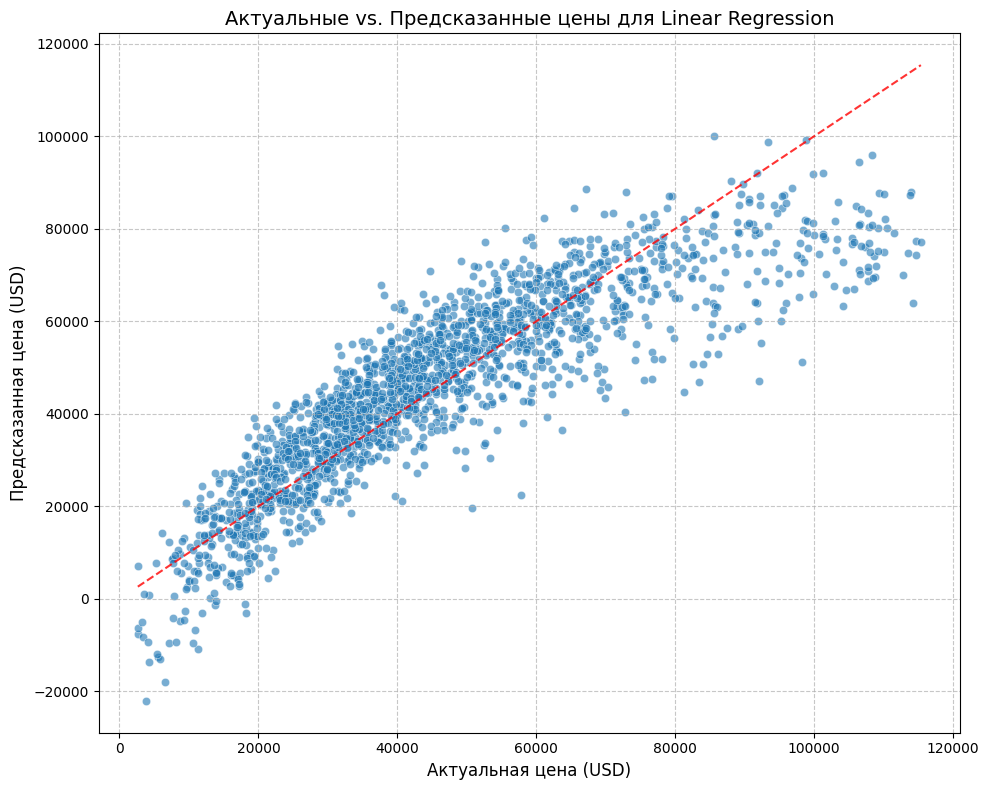

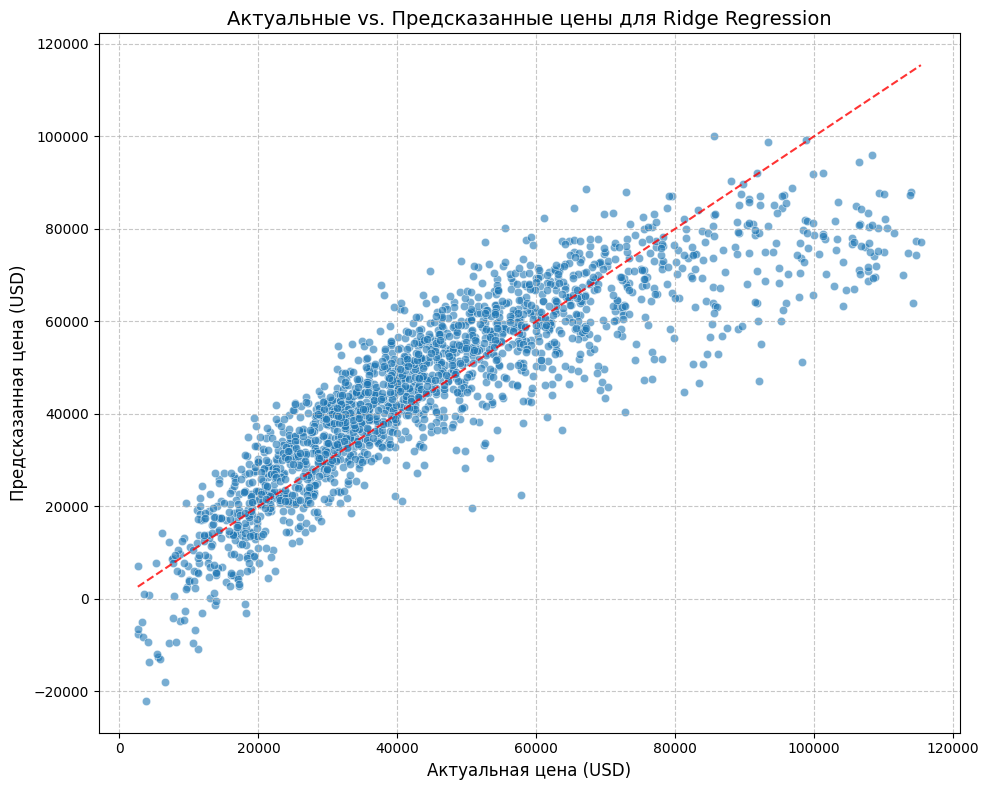

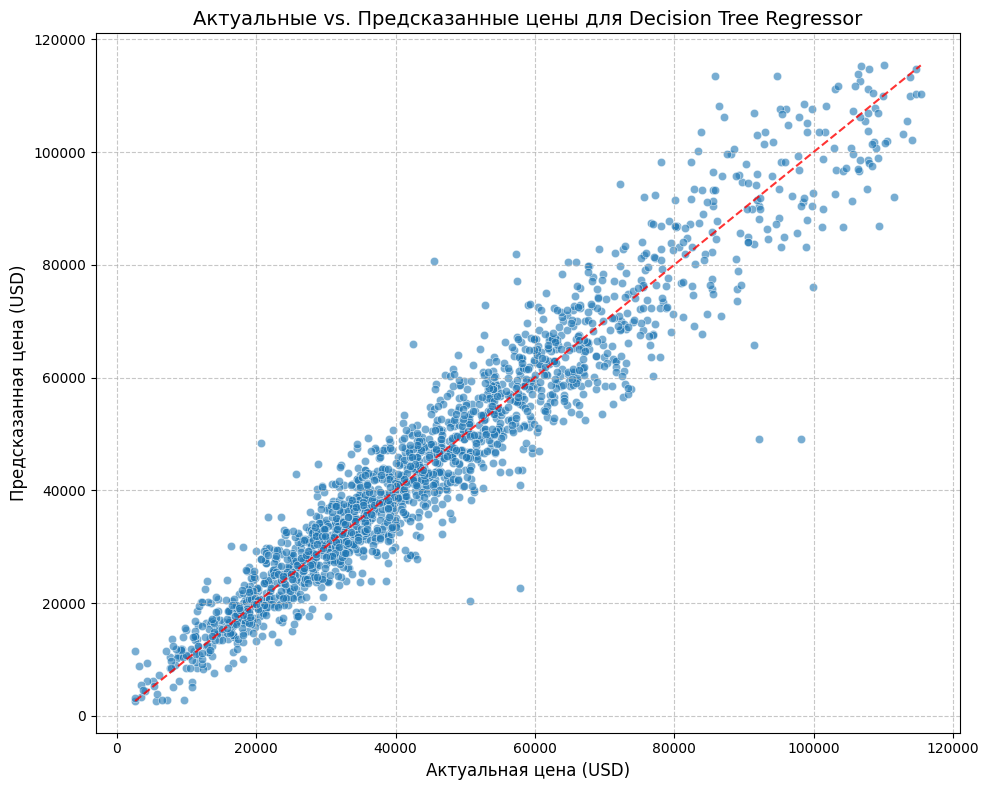

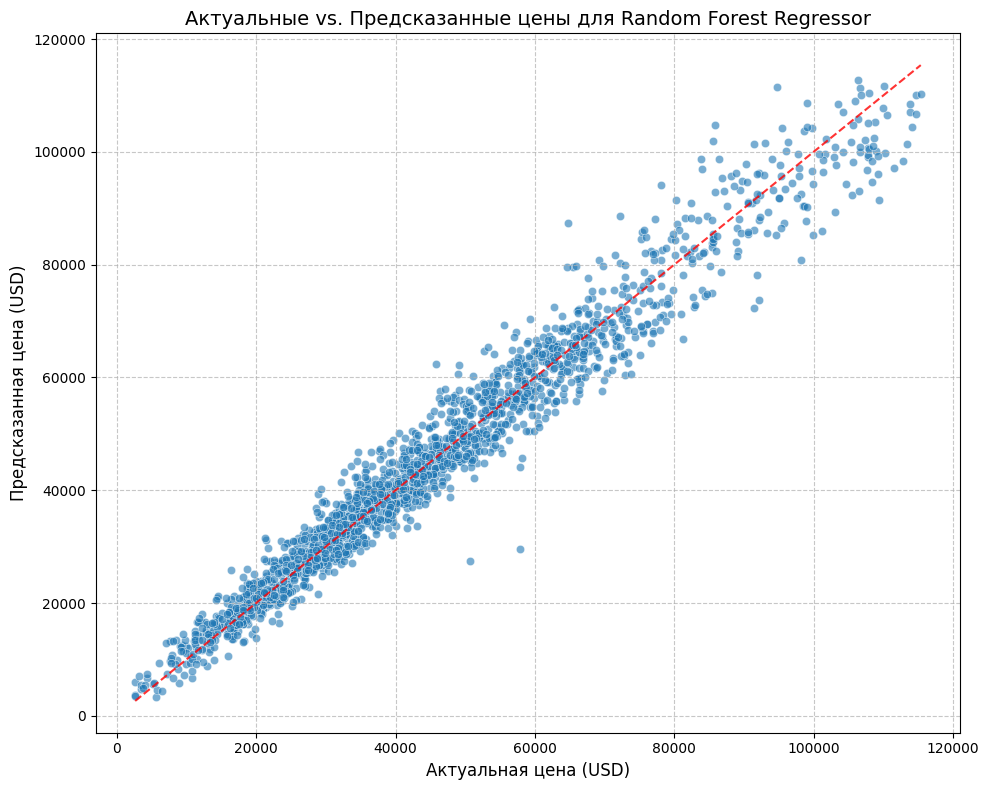

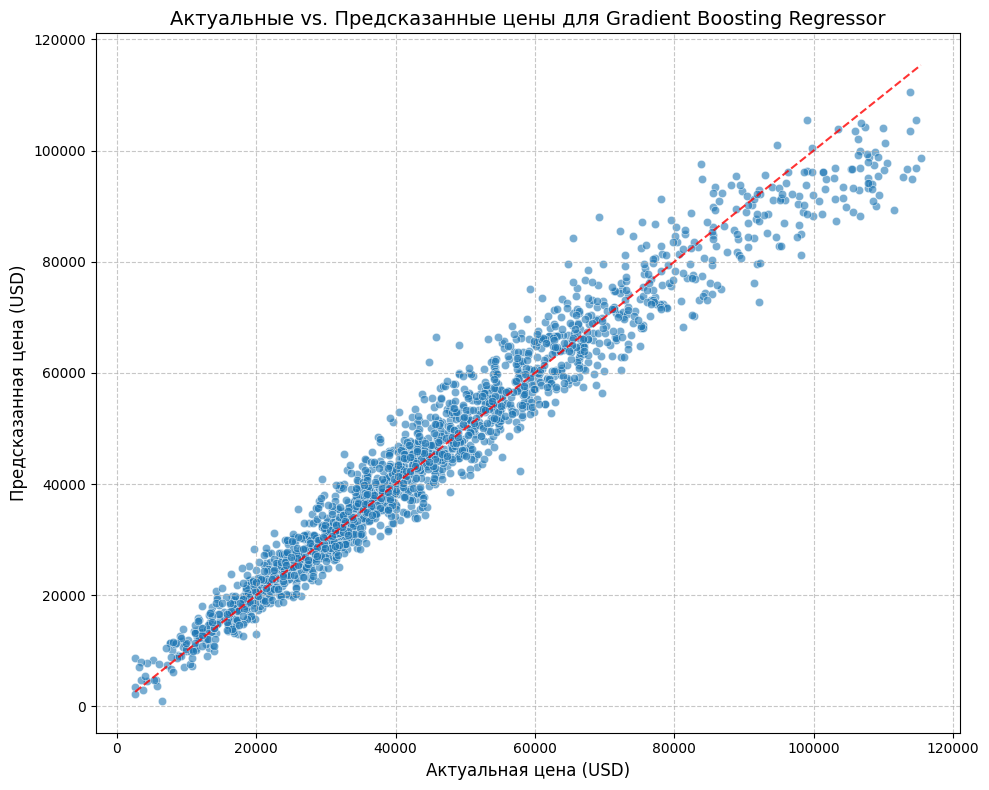

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_train, X_test, y_train, y_test are defined by re-running the split if needed
# This step is included for robustness in case the notebook state is reset partially
if 'X_train' not in locals() or 'X_test' not in locals() or 'y_train' not in locals() or 'y_test' not in locals():
    X = df_no_outliers.drop('price_usd', axis=1)
    y = df_no_outliers['price_usd']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-initialize and train models to ensure they are available in the current context
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)

# Visualize actual vs. predicted prices for ALL models
for name, model in models.items():
    y_pred = model.predict(X_test)

    plot_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    plot_df['Model'] = data.loc[y_test.index, 'model'] # Assuming 'data' (original df) is still available for original model names

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='Actual', y='Predicted', data=plot_df, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', alpha=0.8) # Diagonal line for perfect prediction
    plt.title(f'Актуальные vs. Предсказанные цены для {name}', fontsize=14)
    plt.xlabel('Актуальная цена (USD)', fontsize=12)
    plt.ylabel('Предсказанная цена (USD)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


Starting model training and evaluation...

Training Linear Regression...
  Linear Regression - R2: 0.7643, RMSE: 11250.34, MAE: 8447.38

Training Ridge Regression...
  Ridge Regression - R2: 0.7644, RMSE: 11250.28, MAE: 8447.02

Training Decision Tree Regressor...
  Decision Tree Regressor - R2: 0.9244, RMSE: 6373.71, MAE: 4721.74

Training Random Forest Regressor...
  Random Forest Regressor - R2: 0.9606, RMSE: 4602.52, MAE: 3428.98

Training Gradient Boosting Regressor...
  Gradient Boosting Regressor - R2: 0.9551, RMSE: 4911.40, MAE: 3658.51

Model Evaluation Results:

                                   R2          RMSE          MAE
Linear Regression            0.764348  11250.343112  8447.383615
Ridge Regression             0.764351  11250.275750  8447.023095
Decision Tree Regressor      0.924365   6373.714755  4721.738600
Random Forest Regressor      0.960560   4602.523293  3428.982395
Gradient Boosting Regressor  0.955089   4911.404158  3658.512728


/tmp/ipykernel_10466/2710364459.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_10466/2710364459.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='RMSE', data=results_df, ax=axes[1], palette='viridis')
/tmp/ipykernel_10466/2710364459.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='MAE', data=results_df, ax=axes[2], palette='viridis')


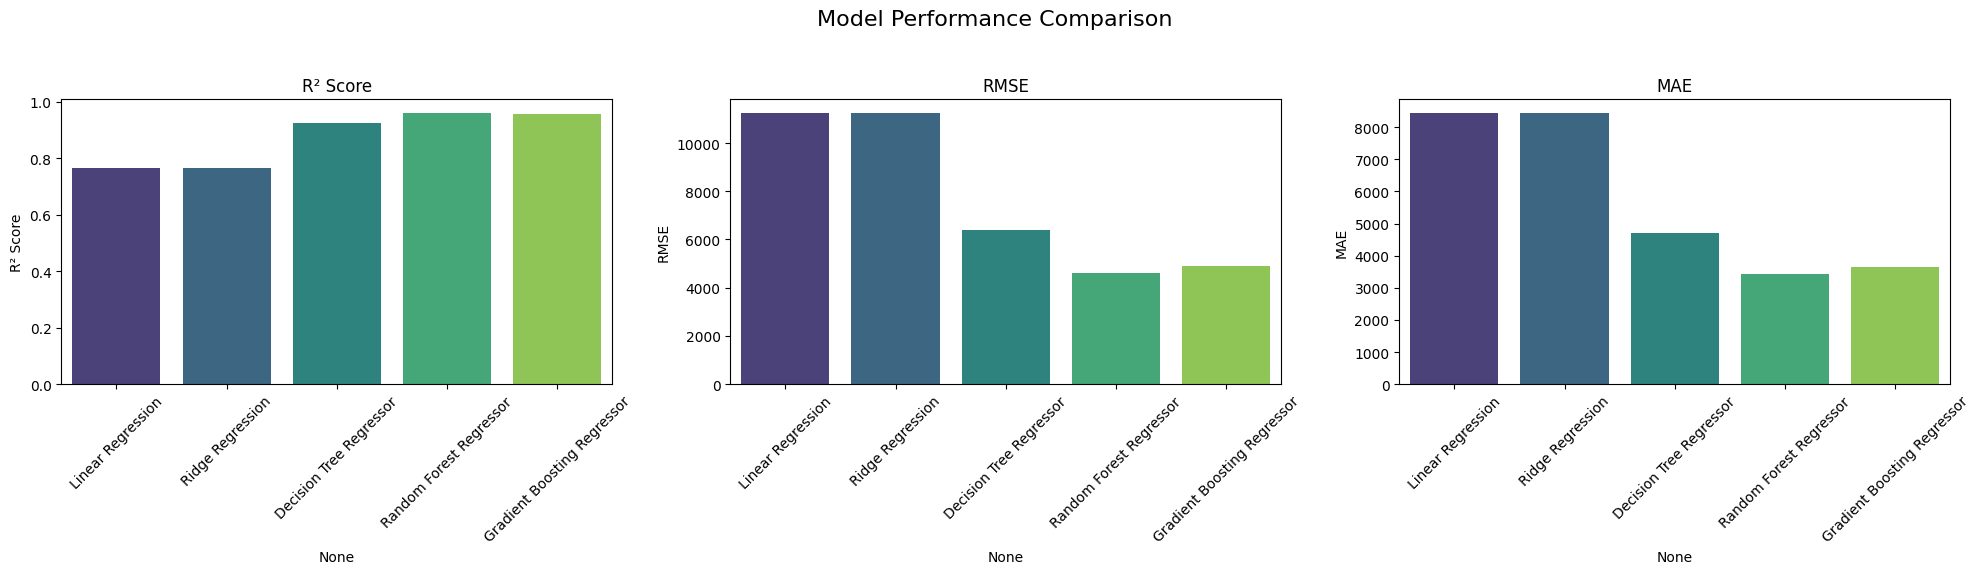


Best model based on R² score: Random Forest Regressor (R²: 0.9606)
Best model based on RMSE: Random Forest Regressor (RMSE: 4602.52)
Best model based on MAE: Random Forest Regressor (MAE: 3428.98)

Overall best performing model (based on highest R²): Random Forest Regressor


In [27]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize five different regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

results = {}

print("Starting model training and evaluation...\n")

for name, model in models.items():
    print(f"Training {name}...")
    # 2. Train each model using the training data
    model.fit(X_train, y_train)

    # 3. Make predictions on the test data
    y_pred = model.predict(X_test)

    # 4. Calculate the R² score, RMSE, and MAE
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # 5. Store these evaluation metrics for each model
    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f"  {name} - R2: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}\n")

# 6. Compare the performance of the models
results_df = pd.DataFrame(results).T
print("Model Evaluation Results:\n")
print(results_df)

# 7. Visualize the R², RMSE, and MAE for all models using bar plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# R2 Score Plot
sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('R² Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('R² Score')

# RMSE Plot
sns.barplot(x=results_df.index, y='RMSE', data=results_df, ax=axes[1], palette='viridis')
axes[1].set_title('RMSE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('RMSE')

# MAE Plot
sns.barplot(x=results_df.index, y='MAE', data=results_df, ax=axes[2], palette='viridis')
axes[2].set_title('MAE')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('MAE')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

# Identify and print the best performing model based on R2, RMSE, and MAE
best_r2_model = results_df['R2'].idxmax()
best_rmse_model = results_df['RMSE'].idxmin()
best_mae_model = results_df['MAE'].idxmin()

print(f"\nBest model based on R² score: {best_r2_model} (R²: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on RMSE: {best_rmse_model} (RMSE: {results_df.loc[best_rmse_model, 'RMSE']:.2f})")
print(f"Best model based on MAE: {best_mae_model} (MAE: {results_df.loc[best_mae_model, 'MAE']:.2f})")

print(f"\nOverall best performing model (based on highest R²): {best_r2_model}")


Starting model training and evaluation...

Training Linear Regression...
  Linear Regression - R2: 0.7643, RMSE: 11250.34, MAE: 8447.38

Training Ridge Regression...
  Ridge Regression - R2: 0.7644, RMSE: 11250.28, MAE: 8447.02

Training Decision Tree Regressor...
  Decision Tree Regressor - R2: 0.9244, RMSE: 6373.71, MAE: 4721.74

Training Random Forest Regressor...
  Random Forest Regressor - R2: 0.9606, RMSE: 4602.52, MAE: 3428.98

Training Gradient Boosting Regressor...
  Gradient Boosting Regressor - R2: 0.9551, RMSE: 4911.40, MAE: 3658.51

Model Evaluation Results:

                                   R2          RMSE          MAE
Linear Regression            0.764348  11250.343112  8447.383615
Ridge Regression             0.764351  11250.275750  8447.023095
Decision Tree Regressor      0.924365   6373.714755  4721.738600
Random Forest Regressor      0.960560   4602.523293  3428.982395
Gradient Boosting Regressor  0.955089   4911.404158  3658.512728


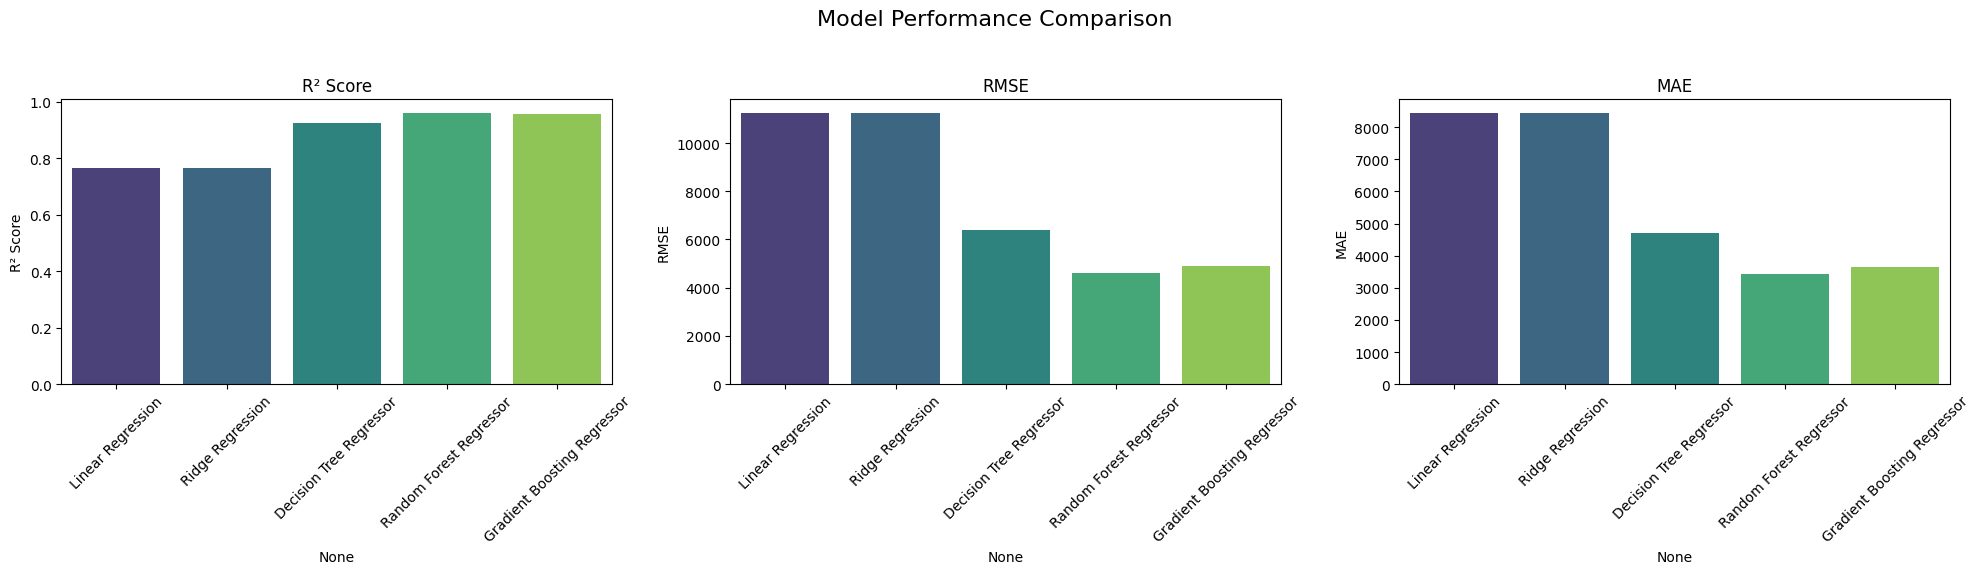


Best model based on R² score: Random Forest Regressor (R²: 0.9606)
Best model based on RMSE: Random Forest Regressor (RMSE: 4602.52)
Best model based on MAE: Random Forest Regressor (MAE: 3428.98)

Overall best performing model (based on highest R²): Random Forest Regressor


In [31]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize five different regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

results = {}

print("Starting model training and evaluation...\n")

for name, model in models.items():
    print(f"Training {name}...")
    # 2. Train each model using the training data
    model.fit(X_train, y_train)

    # 3. Make predictions on the test data
    y_pred = model.predict(X_test)

    # 4. Calculate the R² score, RMSE, and MAE
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # 5. Store these evaluation metrics for each model
    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f"  {name} - R2: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}\n")

# 6. Compare the performance of the models
results_df = pd.DataFrame(results).T
print("Model Evaluation Results:\n")
print(results_df)

# 7. Visualize the R², RMSE, and MAE for all models using bar plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# R2 Score Plot
sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[0], palette='viridis', hue=results_df.index, legend=False)
axes[0].set_title('R² Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('R² Score')

# RMSE Plot
sns.barplot(x=results_df.index, y='RMSE', data=results_df, ax=axes[1], palette='viridis', hue=results_df.index, legend=False)
axes[1].set_title('RMSE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('RMSE')

# MAE Plot
sns.barplot(x=results_df.index, y='MAE', data=results_df, ax=axes[2], palette='viridis', hue=results_df.index, legend=False)
axes[2].set_title('MAE')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('MAE')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

# Identify and print the best performing model based on R2, RMSE, and MAE
best_r2_model = results_df['R2'].idxmax()
best_rmse_model = results_df['RMSE'].idxmin()
best_mae_model = results_df['MAE'].idxmin()

print(f"\nBest model based on R² score: {best_r2_model} (R²: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on RMSE: {best_rmse_model} (RMSE: {results_df.loc[best_rmse_model, 'RMSE']:.2f})")
print(f"Best model based on MAE: {best_mae_model} (MAE: {results_df.loc[best_mae_model, 'MAE']:.2f})")

print(f"\nOverall best performing model (based on highest R²): {best_r2_model}")